<a href="https://colab.research.google.com/github/Rageel-28/244107020136-Machine-Learning/blob/main/minggu3/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


 Mengubah tingkat kecerahan citra 
-----------------------------------
Masukkan nilai kecerahan: 30


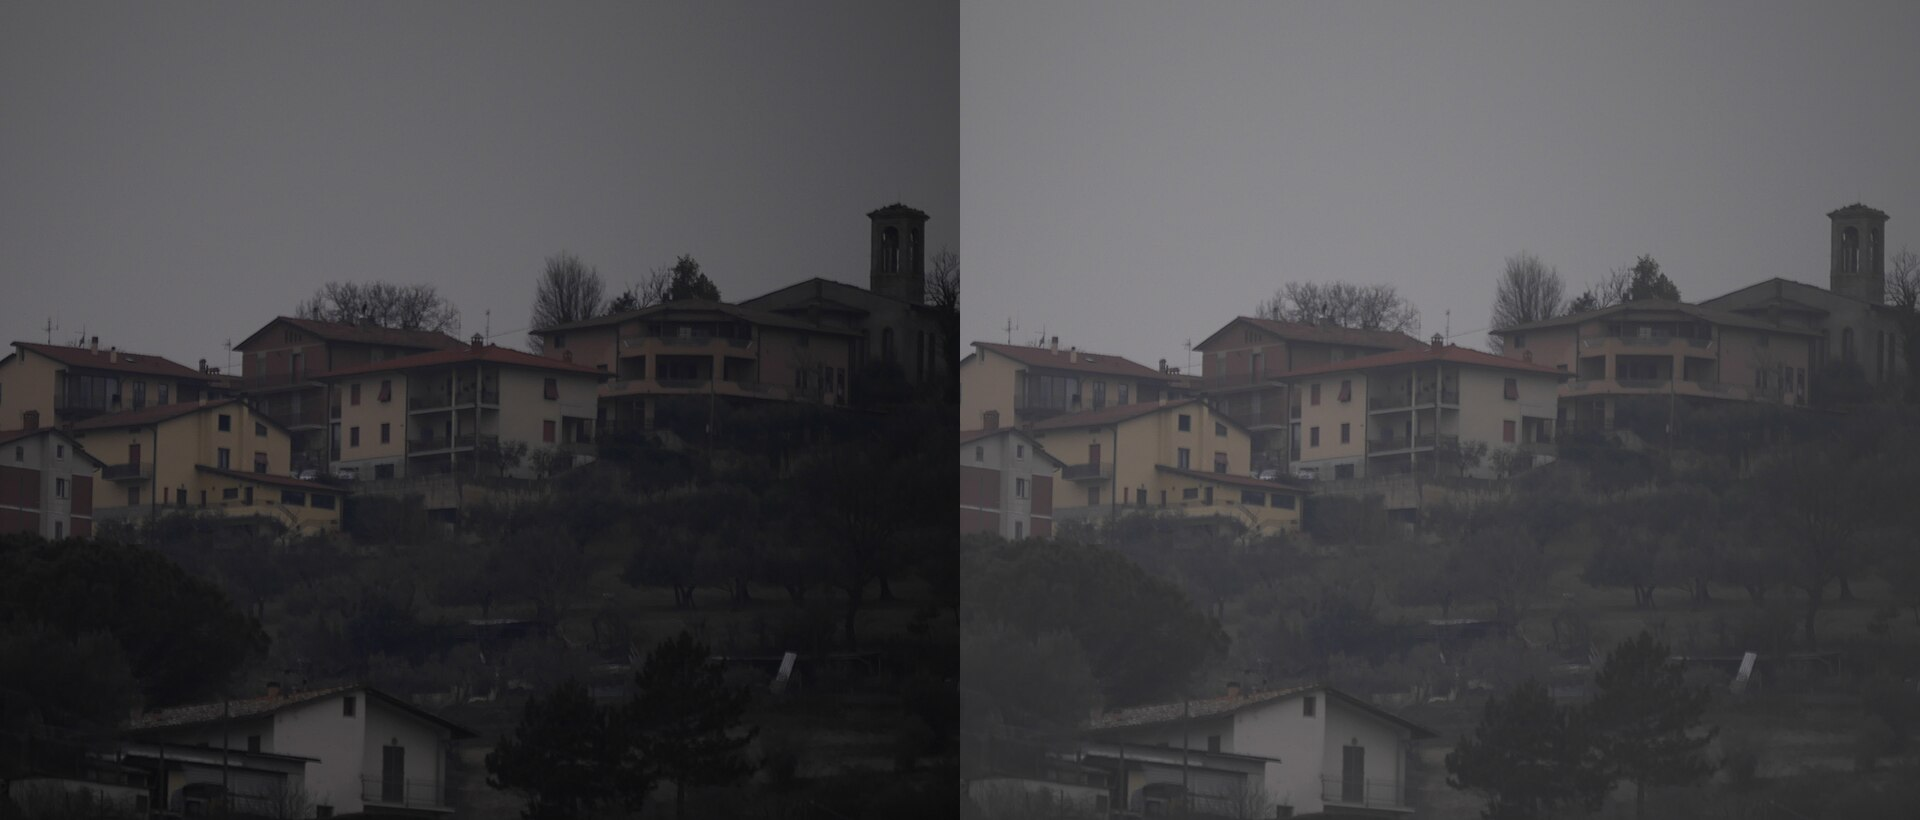

In [ ]:
print(' Mengubah tingkat kecerahan citra ')
print('-----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/PCVK/Images/houses.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

TUGAS **PRAKTIKUM**

1.Invers citra

 Inverse Citra 
-----------------------------------


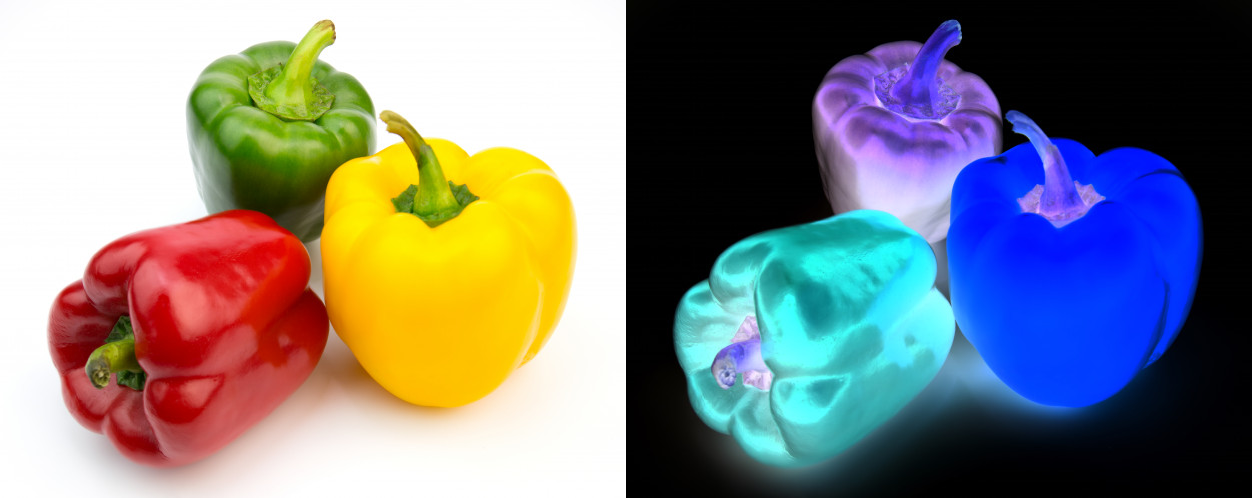

In [ ]:
print(' Inverse Citra ')
print('-----------------------------------')


original = cv.imread('/content/drive/MyDrive/PCVK/Images/peppers.jpg')
inverse_image = np.zeros(original.shape, original.dtype)

#akses per piksel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            inverse_image[y,x,c] = np.clip(255 - original[y,x,c], 0, 255)

#cara simple tanpa for loop
#inverse_image = 255 - original

final_frame = cv.hconcat((original, inverse_image))
cv2_imshow(final_frame)

2. Implementasikan transformasi contrast pada Google Colaboratory menggunakan
formula yang terdapat pada bagian Ulasan Teori untuk kontras, sehingga
menghasilkan keluaran seperti berikut:

 Mengubah kontras dan tingkat kecerahan citra 
-----------------------------------------------
Masukkan tingkat kecerahan : 10
Masukkan kontras : 1.5


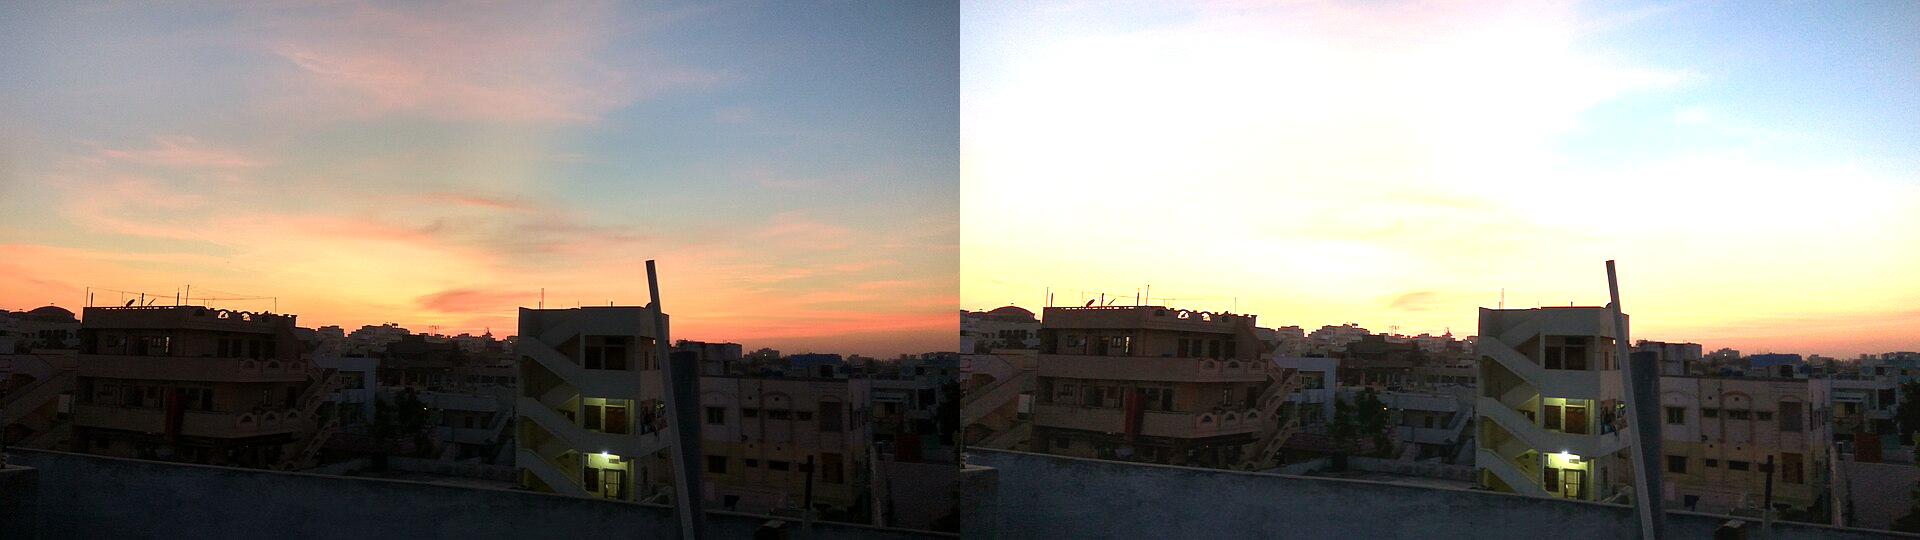

In [ ]:
print(' Mengubah kontras dan tingkat kecerahan citra ')
print('-----------------------------------------------')
try:
    brightness = int(input('Masukkan tingkat kecerahan : '))
    contrast = float(input('Masukkan kontras : '))
except ValueError:
    print('Error, not a number')


original = cv.imread('/content/drive/MyDrive/PCVK/Images/sunset.jpg')
contrast_image = np.zeros(original.shape, original.dtype)

#akses per piksel — g(x,y) = a*f(x,y) + b
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            nilai_baru = contrast * original[y,x,c] + brightness
            contrast_image[y,x,c] = np.clip(nilai_baru, 0, 255)

final_frame = cv.hconcat((original, contrast_image))
cv2_imshow(final_frame)

3. Implementasikan transformasi logarithmic brightness pada Google Colaboratory
menggunakan formula yang terdapat pada bagian Ulasan Teori untuk transformasi
log, sehingga menghasilkan keluaran seperti berikut

 Mengubah tingkat kecerahan citra dengan Transformasi Log 
---------------------------------------------------------
Masukkan nilai kecerahan: 50


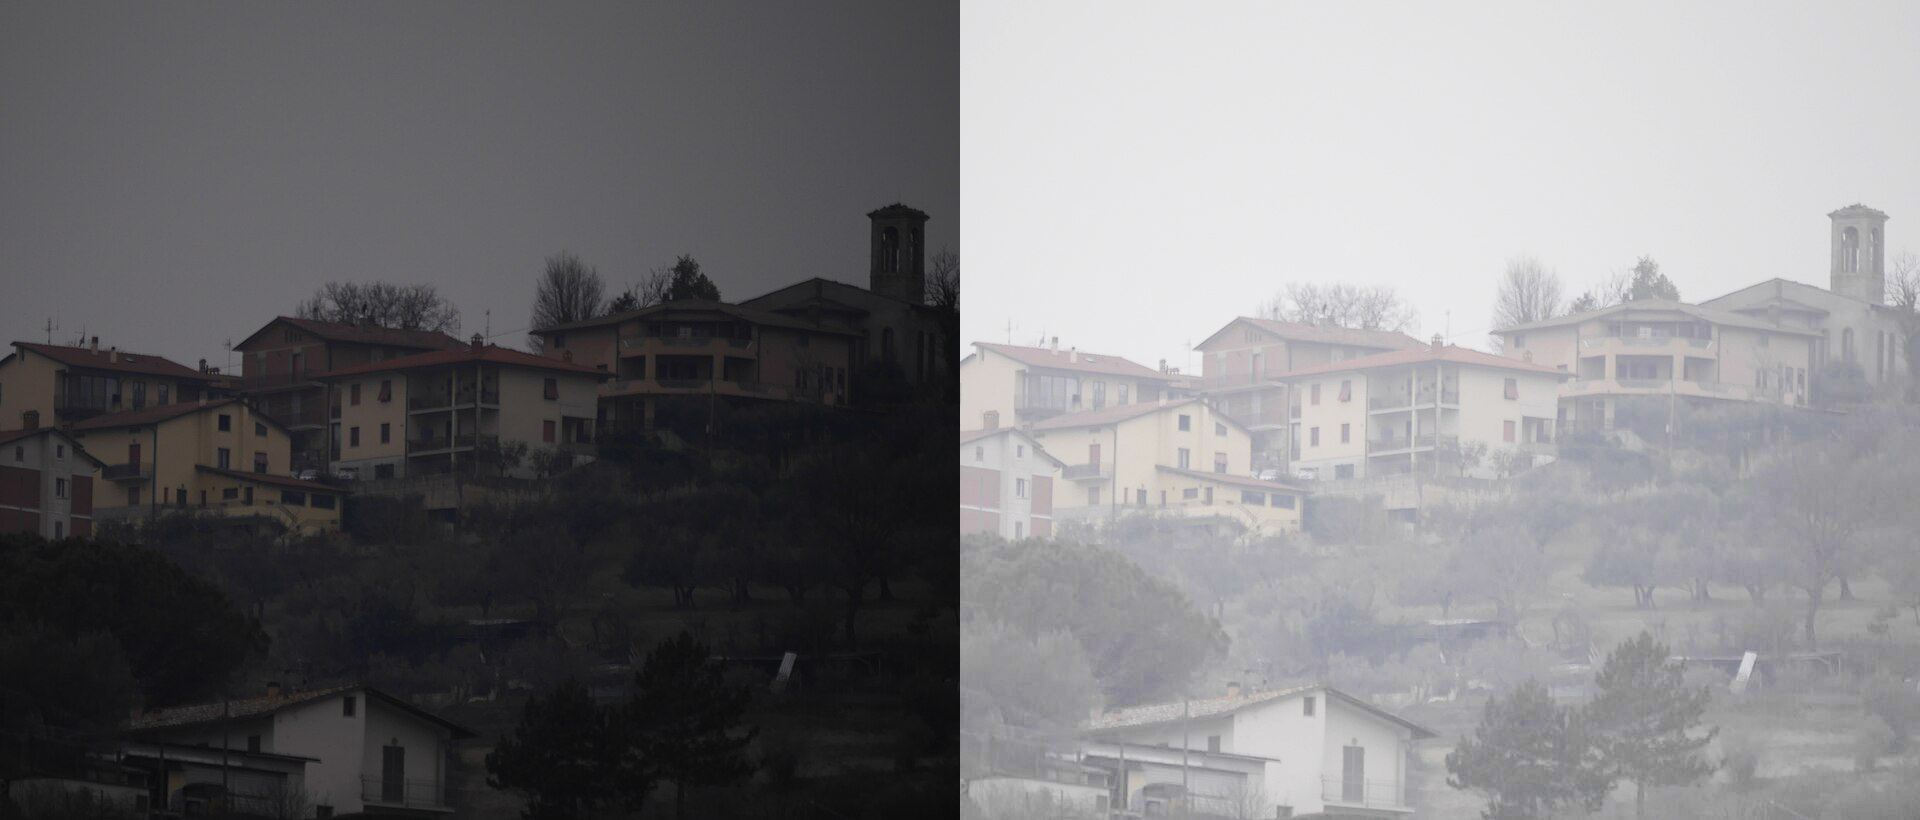

In [ ]:
print(' Mengubah tingkat kecerahan citra dengan Transformasi Log ')
print('---------------------------------------------------------')
try:
    c = float(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

Z
original = cv.imread('/content/drive/MyDrive/PCVK/Images/houses.jpg')
log_image = np.zeros(original.shape, original.dtype)

#akses per piksel — s = c * log(1 + r)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c_channel in range(original.shape[2]):
            r = float(original[y,x,c_channel])
            s = c * np.log(1 + r)
            log_image[y,x,c_channel] = np.clip(s, 0, 255)

final_frame = cv.hconcat((original, log_image))
cv2_imshow(final_frame)

4. Implementasikan transformasi grayscale menggunakan metode averaging, lightness,
dan luminance pada Google Colaboratory menggunakan formula yang terdapat pada
bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:

In [ ]:

original = cv.imread('/content/drive/MyDrive/PCVK/Images/peppers.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# siapkan array grayscale (2 dimensi saja, tanpa channel warna)
avg_image = np.zeros((original.shape[0], original.shape[1]), np.uint8)
lightness_image = np.zeros((original.shape[0], original.shape[1]), np.uint8)
luminance_image = np.zeros((original.shape[0], original.shape[1]), np.uint8)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        B = int(original[y,x,0])
        G = int(original[y,x,1])
        R = int(original[y,x,2])

        # a. Averaging
        avg_image[y,x] = np.clip((R + G + B) / 3, 0, 255)

        # b. Lightness
        lightness_image[y,x] = np.clip((max(R,G,B) + min(R,G,B)) / 2, 0, 255)

        # c. Luminance
        luminance_image[y,x] = np.clip(0.21*R + 0.72*G + 0.07*B, 0, 255)


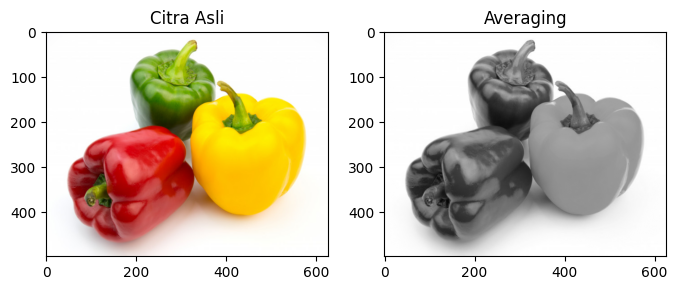

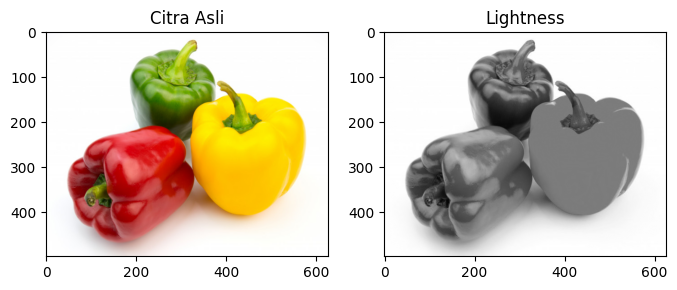

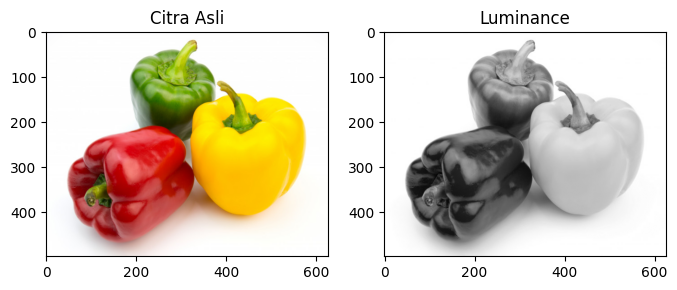

In [ ]:
# a. Averaging
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(original_rgb); plt.title('Citra Asli')
plt.subplot(1,2,2); plt.imshow(avg_image, cmap='gray'); plt.title('Averaging')
plt.show()

# b. Lightness
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(original_rgb); plt.title('Citra Asli')
plt.subplot(1,2,2); plt.imshow(lightness_image, cmap='gray'); plt.title('Lightness')
plt.show()

# c. Luminance
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(original_rgb); plt.title('Citra Asli')
plt.subplot(1,2,2); plt.imshow(luminance_image, cmap='gray'); plt.title('Luminance')
plt.show()

5. Tampilkanlah warna tertentu pada citra, dan ubah warna lain menjadi grayscale. Misal,
tampilkan warna merah pada citra masukan dan ubah bagian lain yang tidak berwarna
merah menjadi grayscale seperti pada contoh berikut:

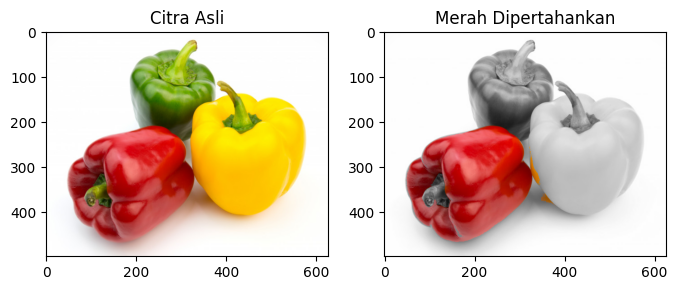

In [ ]:

original = cv.imread('/content/drive/MyDrive/PCVK/Images/peppers.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

result_image = np.zeros(original.shape, np.uint8)

threshold = 30  # ambang batas selisih R terhadap G dan B

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        B = int(original[y,x,0])
        G = int(original[y,x,1])
        R = int(original[y,x,2])

        is_merah = (R - G > threshold) and (R - B > threshold) and (G < R * 0.6)

        if is_merah:
            # piksel merah -> pertahankan warna asli (urutan R,G,B, BUKAN B,G,R)
            result_image[y,x,0] = R
            result_image[y,x,1] = G
            result_image[y,x,2] = B
        else:
            # bukan merah -> ubah jadi grayscale (Luminance)
            gray = np.clip(0.21*R + 0.72*G + 0.07*B, 0, 255)
            result_image[y,x,0] = gray
            result_image[y,x,1] = gray
            result_image[y,x,2] = gray

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(original_rgb); plt.title('Citra Asli')
plt.subplot(1,2,2); plt.imshow(result_image); plt.title('Merah Dipertahankan')
plt.show()

6. Buat Gamma Correction sesuai dengan petunjuk berikut
Percobaan ini akan meminta anda membuat Gamma Correction. Pada percobaan ini, nilai
Gamma akan diset dengan meminta masukan dari pengguna. Berikut adalah kode untuk
meminta masukan nilai dari pengguna. Lanjutkan kode tersebut dengan membuat image
dengan gamma correction sesuai rumus yang telah diberikan.

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 1.5


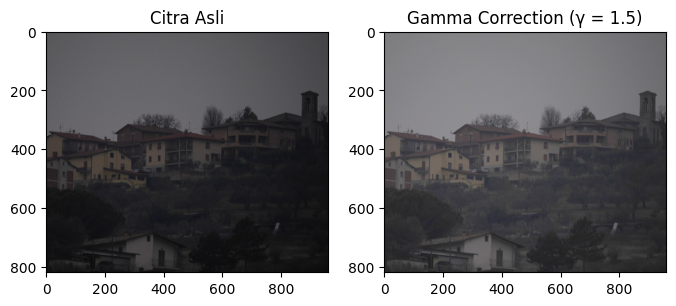

In [13]:
print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')


original = cv.imread('/content/drive/MyDrive/PCVK/Images/houses.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

gamma_image = np.zeros(original.shape, original.dtype)

#akses per piksel — I' = 255 * (I/255)^(1/gamma)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            I = float(original[y,x,c])
            I_baru = 255 * (I/255) ** (1/gamma)
            gamma_image[y,x,c] = np.clip(I_baru, 0, 255)

gamma_image_rgb = cv.cvtColor(gamma_image, cv.COLOR_BGR2RGB)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(original_rgb); plt.title('Citra Asli')
plt.subplot(1,2,2); plt.imshow(gamma_image_rgb); plt.title(f'Gamma Correction (γ = {gamma})')
plt.show()

7. Buat Simulasi Image Depth
Percobaan ini digunakan sebagai simulasi dari proses kuantisasi citra. Pada kuantisasi
citra, pixel dapat direpresentasikan dengan n-bit kedalaman (default menggunakan 8-bit).
Pada pixel 8-bit, warna yang memungkinkan adalah 256 warna, dari 0 (0000 0000) hingga
255(1111 1111). Pada pixel 7-bit, warna yang memungkinkan adalah 128 warna, dari 0
(000 0000) hingga 127 (111 1111). Kemungkinan warna didapat dari pangkat 2 jumlah bit.
Jika 7bit, maka jumlah warnanya adalah 27 = 128, dst.
Berikut adalah kode untuk membaca citra masukan dan memberi nilai kedalaman citra,
silahkan lanjutkan kode program berikut sehingga menghasilkan keluaran seperti contoh
pada Gambar.

Masukkan bit depth tujuan (1-8): 3
Bit depth awal  : 8 bit
Bit depth tujuan: 3 bit
Jumlah level    : 8


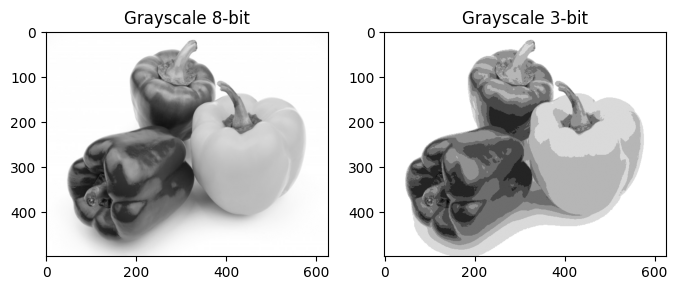

In [ ]:
try:
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
except ValueError:
    print('Error, not a number')

print(f'Bit depth awal  : 8 bit')
print(f'Bit depth tujuan: {bit_depth} bit')
jumlah_level = pow(2, bit_depth)
print(f'Jumlah level    : {jumlah_level}')

level = 255 / (pow(2,bit_depth)-1)

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/PCVK/Images/peppers.jpg', cv.IMREAD_GRAYSCALE)
depth_image = np.zeros(original.shape, original.dtype)

#akses per piksel — C' = round((C/level) * level)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        C = float(original[y,x])
        C_baru = round((C/level)) * level
        depth_image[y,x] = np.clip(C_baru, 0, 255)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(original, cmap='gray'); plt.title('Grayscale 8-bit')
plt.subplot(1,2,2); plt.imshow(depth_image, cmap='gray'); plt.title(f'Grayscale {bit_depth}-bit')
plt.show()

8. Buat modul Average Denoising
Buat modul average denoising sesuai dengan rumus yang telah diberikan pada sub bab
sebelumnya.
Citra asli sudah disediakan pada /images/galaxy.jpg.
100 Citra dengan Gaussian Noise sudah disediakan pada /images/noises/*.jpg
Anda dapat menggunakan code berikut untuk membaca semua image dalam satu folder ,
gunakan modul glob (import glob).

In [6]:
import glob
from math import log10, sqrt

#baca citra asli (ground truth)
galaxy = cv.imread('/content/drive/MyDrive/PCVK/Images/galaxy.jpg')

#baca semua citra ber-noise
cv_img = []
for img in glob.glob('/content/drive/MyDrive/PCVK/Images/noises/*.jpg'):
    n = cv.imread(img)
    cv_img.append(n)

print(f'Jumlah citra noise yang terbaca: {len(cv_img)}')
print(f'Ukuran citra asli: {galaxy.shape}')

Jumlah citra noise yang terbaca: 100
Ukuran citra asli: (256, 310, 3)


In [7]:
def PSNR(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if(mse == 0):  # MSE 0 maka tidak ada noise sama sekali, sehingga PSNR tidak memiliki arti
        return 100
    max_pixel = 255.0
    psnr = 20 * log10(max_pixel / sqrt(mse))
    return psnr

In [8]:
def average_denoise(daftar_citra, jumlah):
    #akumulasi pakai float64 supaya tidak overflow saat dijumlahkan
    hasil = np.zeros(daftar_citra[0].shape, np.float64)
    for i in range(jumlah):
        hasil = hasil + daftar_citra[i].astype(np.float64)
    hasil = hasil / jumlah
    return np.clip(hasil, 0, 255).astype(np.uint8)

#uji sesuai tabel pada modul
jumlah_uji = [10, 20, 40, 80, 100]
hasil_denoise = {}

print('No | Jumlah Citra | Nilai PSNR (dB)')
print('------------------------------------')
for idx, jml in enumerate(jumlah_uji, start=1):
    denoised = average_denoise(cv_img, jml)
    hasil_denoise[jml] = denoised
    nilai_psnr = PSNR(galaxy.astype(np.float64), denoised.astype(np.float64))
    print(f'{idx}. | {jml:12} | {nilai_psnr:.4f}')

No | Jumlah Citra | Nilai PSNR (dB)
------------------------------------
1. |           10 | 19.7251
2. |           20 | 19.8295
3. |           40 | 19.8896
4. |           80 | 19.9181
5. |          100 | 19.9220


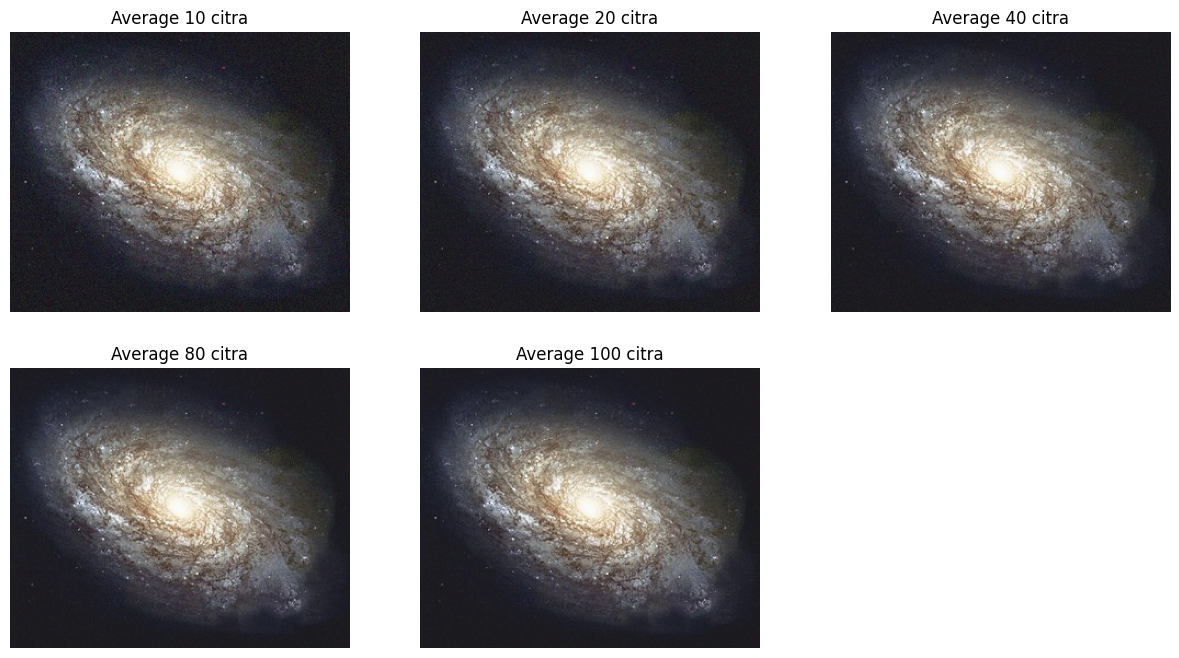

In [9]:
plt.figure(figsize=(15,8))
for idx, jml in enumerate(jumlah_uji, start=1):
    plt.subplot(2, 3, idx)
    plt.imshow(cv.cvtColor(hasil_denoise[jml], cv.COLOR_BGR2RGB))
    plt.title(f'Average {jml} citra')
    plt.axis('off')
plt.show()

9. Buat image masking
Buat image masking untuk image berikut. Image kiri adalah image asli (images/couple.tiff),
sedangkan image paling kanan adalah hasilnya:

Langkah 9a — Baca citra dan buat mask

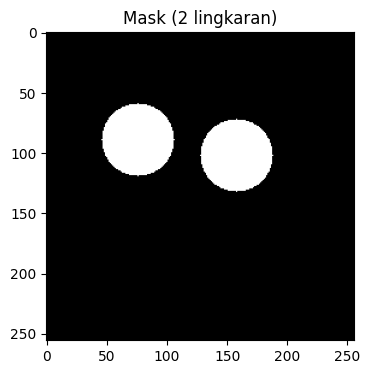

In [10]:

original = cv.imread('/content/drive/MyDrive/PCVK/Images/couple.tiff')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
tinggi, lebar = original.shape[0], original.shape[1]

#buat mask: hitam total, lalu gambar 2 lingkaran putih di posisi wajah
mask = np.zeros((tinggi, lebar), np.uint8)
cv.circle(mask, (int(lebar*0.30), int(tinggi*0.35)), int(lebar*0.12), 255, -1)  # wajah kiri (pria)
cv.circle(mask, (int(lebar*0.62), int(tinggi*0.40)), int(lebar*0.12), 255, -1)  # wajah kanan (wanita)

plt.figure(figsize=(6,4))
plt.imshow(mask, cmap='gray')
plt.title('Mask (2 lingkaran)')
plt.show()

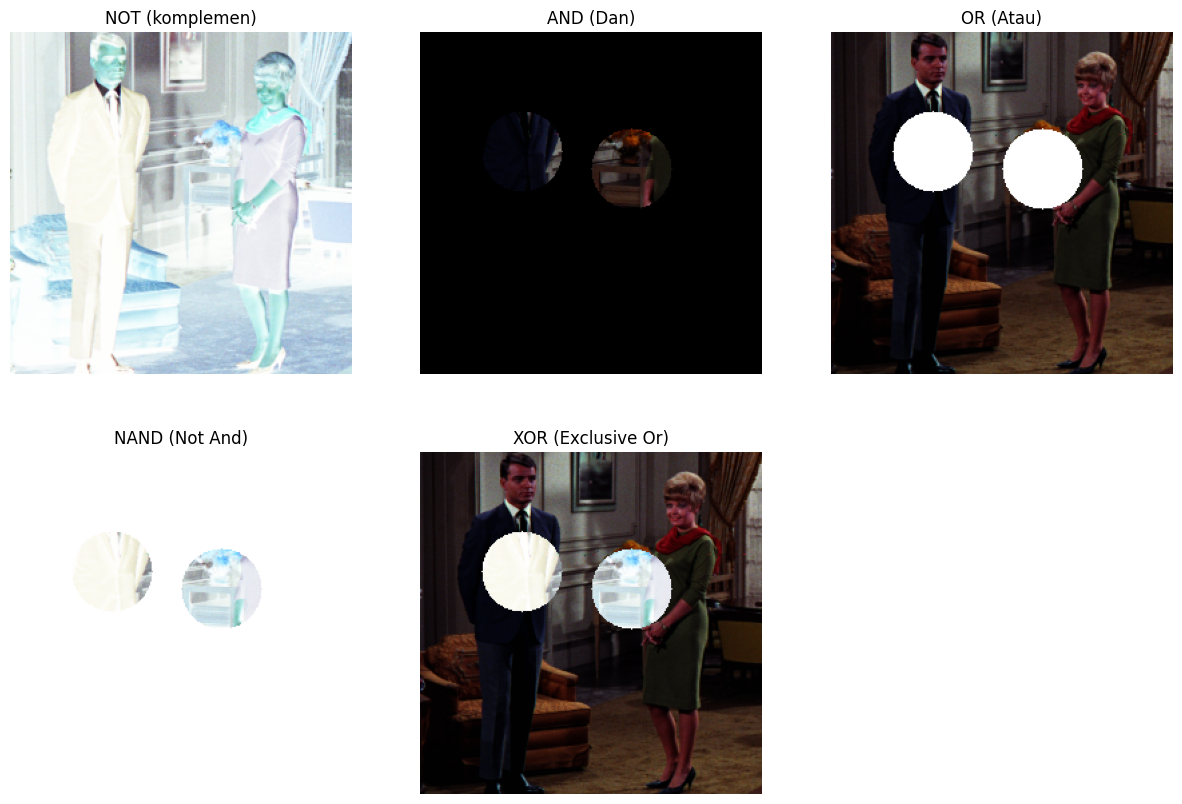

In [11]:
#karena bitwise operator butuh channel yang sama, mask di-3-channel-kan
mask_3ch = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)

hasil_not   = cv.bitwise_not(original)
hasil_and   = cv.bitwise_and(original, mask_3ch)
hasil_or    = cv.bitwise_or(original, mask_3ch)
hasil_nand  = cv.bitwise_not(hasil_and)
hasil_xor   = cv.bitwise_xor(original, mask_3ch)

hasil = {
    'NOT (komplemen)': hasil_not,
    'AND (Dan)': hasil_and,
    'OR (Atau)': hasil_or,
    'NAND (Not And)': hasil_nand,
    'XOR (Exclusive Or)': hasil_xor,
}

plt.figure(figsize=(15,10))
for i, (nama, img) in enumerate(hasil.items(), start=1):
    plt.subplot(2,3,i)
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(nama)
    plt.axis('off')
plt.show()

10. Foto Malam Hari
Carilah foto malam hari yang gelap. Namun, beberapa bagian gambar memiliki detail yang
sebenarnya cukup baik. Pilih salah satu metode berikut dan implementasikan pada foto
tersebut (Linear Brightness, Contrast, Logarithmic Brightness, Gamma Correction). Sebutkan
alasan dan resiko metode yang Anda gunakan.

Masukkan nilai Gamma: 1.5


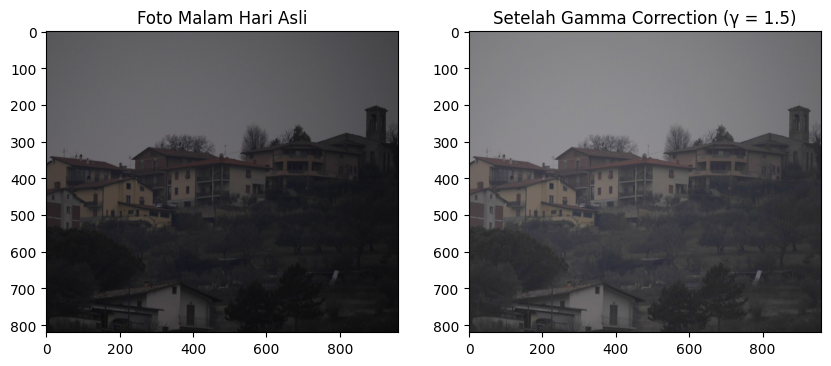

In [16]:
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')


original = cv.imread('/content/drive/MyDrive/PCVK/Images/houses.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

gamma_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            I = float(original[y,x,c])
            I_baru = 255 * (I/255) ** (1/gamma)
            gamma_image[y,x,c] = np.clip(I_baru, 0, 255)

gamma_image_rgb = cv.cvtColor(gamma_image, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(original_rgb); plt.title('Foto Malam Hari Asli')
plt.subplot(1,2,2); plt.imshow(gamma_image_rgb); plt.title(f'Setelah Gamma Correction (γ = {gamma})')
plt.show()

10. Perbaiki kualitas pada citra tersebut dengan metode operasi dasar citra apapun.
Diperbolehkan menggunakan lebih dari 1 metode. Kemudian jelaskan:
• Metode yang dipilih
• Alasan pemilihan
• Menentukan parameter terbaik
• Menghasilkan citra dengan menunjukkan before-after.

Rata-rata channel asli -> B: 107.68, G: 107.03, R: 107.81
Faktor skala koreksi warna -> B: 0.998, G: 1.004, R: 0.997


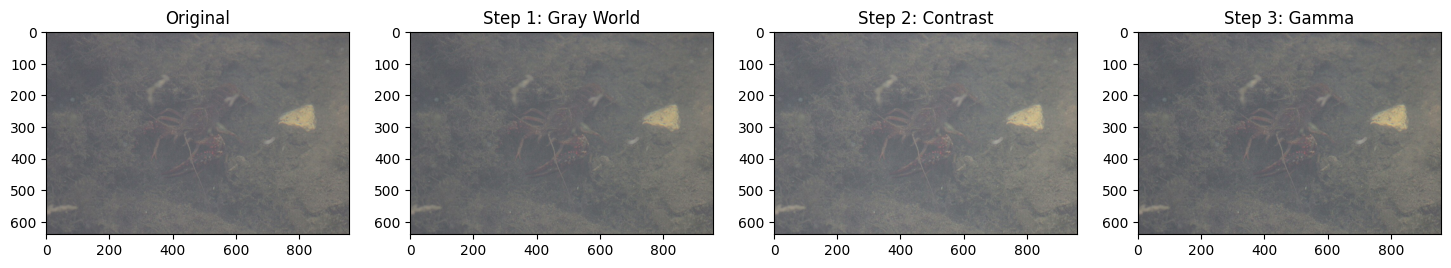

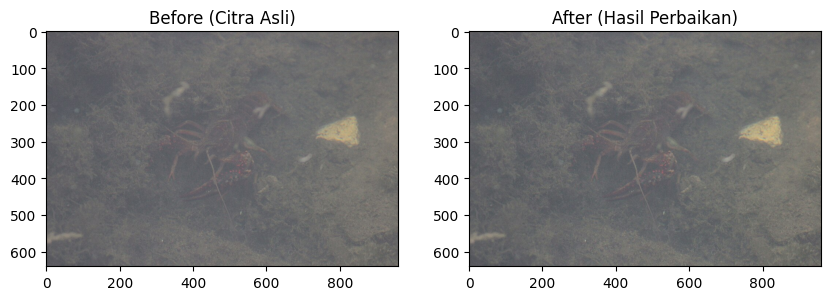

In [19]:
# ===== BACA CITRA ASLI =====
original = cv.imread('/content/drive/MyDrive/PCVK/Images/crayfish.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# ===== TAHAP 1: Koreksi Warna (Gray World Assumption) =====
mean_B = np.mean(original[:,:,0])
mean_G = np.mean(original[:,:,1])
mean_R = np.mean(original[:,:,2])
print(f'Rata-rata channel asli -> B: {mean_B:.2f}, G: {mean_G:.2f}, R: {mean_R:.2f}')

gray_target = (mean_B + mean_G + mean_R) / 3
a_B = gray_target / mean_B
a_G = gray_target / mean_G
a_R = gray_target / mean_R
print(f'Faktor skala koreksi warna -> B: {a_B:.3f}, G: {a_G:.3f}, R: {a_R:.3f}')

step1 = np.zeros(original.shape, original.dtype)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        B = int(original[y,x,0]) * a_B
        G = int(original[y,x,1]) * a_G
        R = int(original[y,x,2]) * a_R
        step1[y,x,0] = np.clip(B, 0, 255)
        step1[y,x,1] = np.clip(G, 0, 255)
        step1[y,x,2] = np.clip(R, 0, 255)

# ===== TAHAP 2: Transformasi Contrast (a*f+b) =====
contrast_a = 1.1   # parameter untuk di-tuning
contrast_b = 0     # parameter untuk di-tuning

step2 = np.zeros(original.shape, original.dtype)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            nilai = contrast_a * int(step1[y,x,c]) + contrast_b
            step2[y,x,c] = np.clip(nilai, 0, 255)

# ===== TAHAP 3: Gamma Correction =====
gamma = 0.9   # parameter untuk di-tuning

step3 = np.zeros(original.shape, original.dtype)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            I = float(step2[y,x,c])
            I_baru = 255 * (I/255) ** (1/gamma)
            step3[y,x,c] = np.clip(I_baru, 0, 255)

# ===== TAMPILKAN SEMUA TAHAP UNTUK VERIFIKASI =====
plt.figure(figsize=(18,5))
plt.subplot(1,4,1); plt.imshow(original_rgb); plt.title('Original')
plt.subplot(1,4,2); plt.imshow(cv.cvtColor(step1, cv.COLOR_BGR2RGB)); plt.title('Step 1: Gray World')
plt.subplot(1,4,3); plt.imshow(cv.cvtColor(step2, cv.COLOR_BGR2RGB)); plt.title('Step 2: Contrast')
plt.subplot(1,4,4); plt.imshow(cv.cvtColor(step3, cv.COLOR_BGR2RGB)); plt.title('Step 3: Gamma')
plt.show()

# ===== BEFORE - AFTER FINAL =====
hasil_akhir_rgb = cv.cvtColor(step3, cv.COLOR_BGR2RGB)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(original_rgb); plt.title('Before (Citra Asli)')
plt.subplot(1,2,2); plt.imshow(hasil_akhir_rgb); plt.title('After (Hasil Perbaikan)')
plt.show()